<a href="https://colab.research.google.com/github/sara-nikkhoo/Data_Analyst_Portfolio/blob/main/churn%20analysis/Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Mount Google Drive to access files
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/projects

/content/drive/MyDrive/projects


#  SECTION 1 — LOAD & INSPECT DATA

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier


In [4]:
train= pd.read_csv('churn_train.csv')
test= pd.read_csv('churn_test.csv')

In [5]:
train.head()

,state,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls,churn
0,OH,107,area_code_415,no,yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,no
1,NJ,137,area_code_415,no,no,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,no
2,OH,84,area_code_408,yes,no,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,no
3,OK,75,area_code_415,yes,no,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,no
4,MA,121,area_code_510,no,yes,24,218.2,88,37.09,348.5,108,29.62,212.6,118,9.57,7.5,7,2.03,3,no


In [6]:
print(f"\nShape      : {train.shape[0]:,} rows × {train.shape[1]} columns")



Shape      : 4,250 rows × 20 columns


In [7]:
print("\n**Column types & nulls")
print(train.info())

print("\n**Numeric summary")
print(train.describe().T)


**Column types & nulls
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4250 entries, 0 to 4249
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   state                          4250 non-null   object 
 1   account_length                 4250 non-null   int64  
 2   area_code                      4250 non-null   object 
 3   international_plan             4250 non-null   object 
 4   voice_mail_plan                4250 non-null   object 
 5   number_vmail_messages          4250 non-null   int64  
 6   total_day_minutes              4250 non-null   float64
 7   total_day_calls                4250 non-null   int64  
 8   total_day_charge               4250 non-null   float64
 9   total_eve_minutes              4250 non-null   float64
 10  total_eve_calls                4250 non-null   int64  
 11  total_eve_charge               4250 non-null   float64
 12  total_night_minutes     

In [8]:
train.area_code= train.area_code.astype('category')
test.area_code= test.area_code.astype('category')

In [9]:
#convert churn col to 1, 0
yes_binary= {'yes':1,'no': 0}
train.churn= train.churn.map(yes_binary)

# SECTION 2 — EXPLORATORY DATA ANALYSIS (EDA)

In [10]:
# Churn rate by International plan
print("\nChurn rate by International Plan")
intl_churn = train.groupby("international_plan")["churn"].mean() * 100
print(intl_churn.round(1).to_string())


Churn rate by International Plan
international_plan
no     11.2
yes    42.2


In [11]:
#  Churn rate by Customer service calls
print("\n**Churn rate by Customer Service Calls")
cs_churn = train.groupby("number_customer_service_calls")["churn"].mean() * 100
print(cs_churn.rename("churn_rate_%").round(1).to_string())
# after 3+ calls, churn rate spikes dramatically



**Churn rate by Customer Service Calls
number_customer_service_calls
0     10.9
1     10.9
2     10.8
3     11.3
4     44.0
5     60.5
6     67.9
7     53.8
8     50.0
9    100.0


In [12]:
#Churn rate by Voice mail plan
print("\n**Churn rate by Voice Mail Plan")
vm_churn = train.groupby("voice_mail_plan")["churn"].mean() * 100
print(vm_churn.round(1).to_string())
#voicemail subscribers churn at half the rate


**Churn rate by Voice Mail Plan
voice_mail_plan
no     16.4
yes     7.4


In [13]:
# chern rate by state
print("\n**Churn rate by State")
state_churn = train.groupby("state")["churn"].mean()
# append whole customer of each state
state_churn = pd.concat([state_churn, train.state.value_counts()], axis=1)
state_churn = state_churn.sort_values(by='churn', ascending=False)
print(state_churn)


**Churn rate by State
          churn  count
state                 
NJ     0.270833     96
CA     0.256410     39
WA     0.225000     80
MD     0.220930     86
MT     0.212500     80
OK     0.205128     78
NV     0.204819     83
SC     0.194444     72
TX     0.193878     98
MS     0.182927     82
ME     0.179775     89
MN     0.175926    108
MI     0.172414     87
KS     0.172414     87
CT     0.170455     88
NY     0.166667     96
DE     0.162500     80
MA     0.157303     89
IN     0.156627     83
AR     0.154930     71
TN     0.151899     79
OR     0.151515     99
SD     0.146667     75
KY     0.141176     85
WV     0.136691    139
AL     0.128713    101
NH     0.128205     78
NM     0.128205     78
OH     0.126316     95
MO     0.125000     80
UT     0.123711     97
PA     0.119403     67
FL     0.118421     76
VT     0.116279     86
ID     0.113208    106
IA     0.112903     62
CO     0.112500     80
DC     0.111111     72
GA     0.109375     64
WY     0.105263     95
LA     0.10

## Visualization

<Axes: xlabel='churn', ylabel='count'>

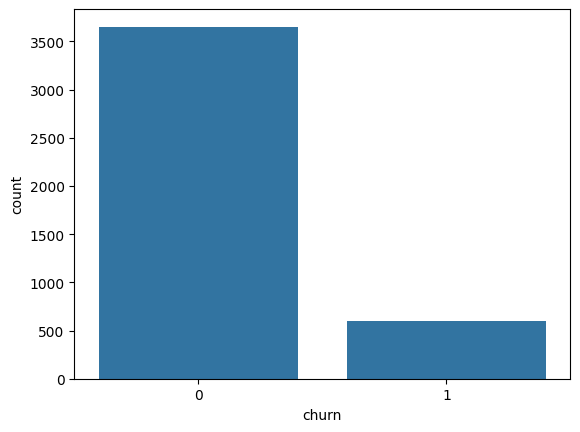

In [14]:
sns.countplot(x='churn',data= train)

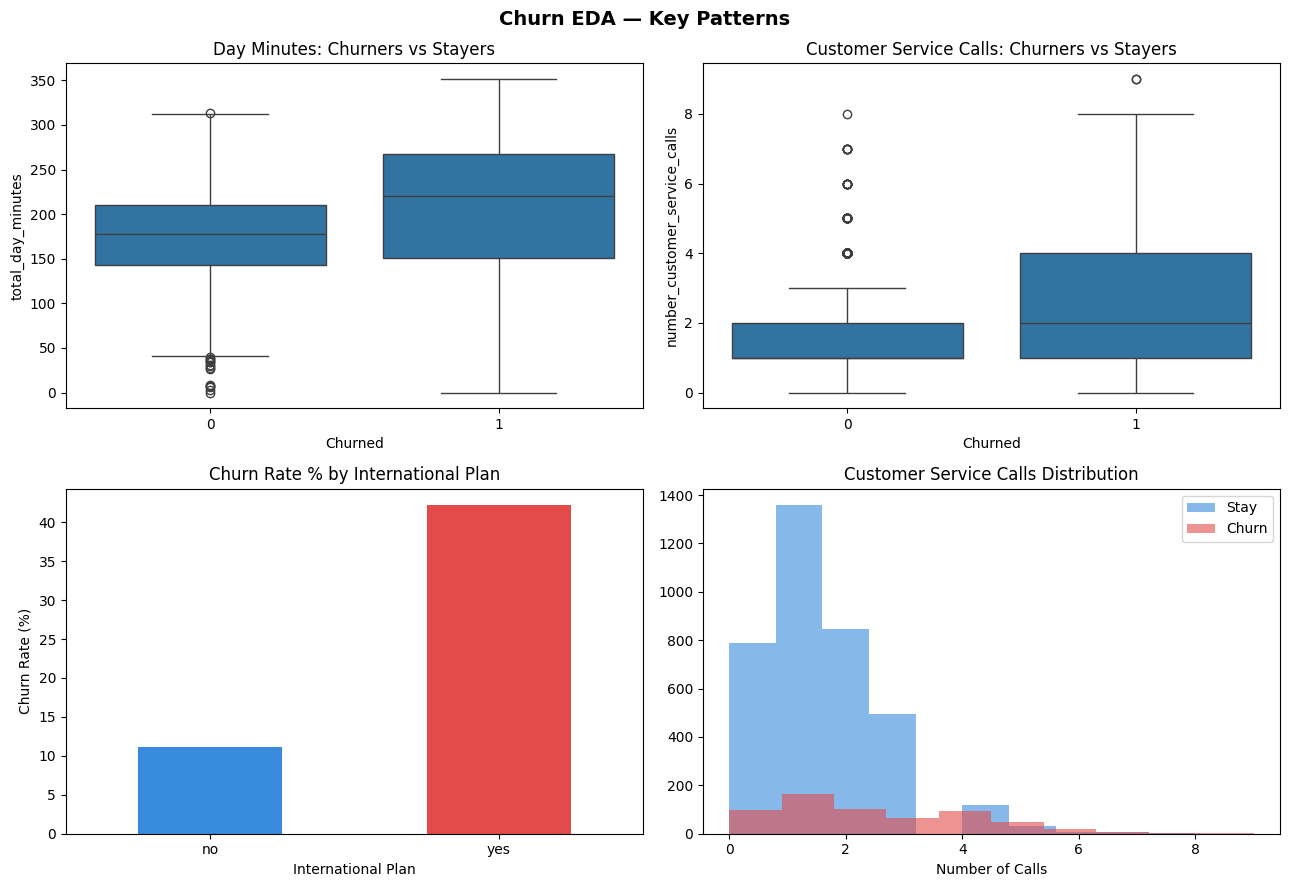

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Churn EDA — Key Patterns", fontsize=14, fontweight="bold")

# Box: total day minutes vs churn
sns.boxplot(x="churn", y="total_day_minutes", data=train,
             ax=axes[0, 0])
axes[0, 0].set_title("Day Minutes: Churners vs Stayers")
axes[0, 0].set_xlabel("Churned")

# Box: customer service calls vs churn
sns.boxplot(x="churn", y="number_customer_service_calls", data=train,
             ax=axes[0, 1])
axes[0, 1].set_title("Customer Service Calls: Churners vs Stayers")
axes[0, 1].set_xlabel("Churned")

# Bar: churn rate by international plan
intl_churn.plot(kind="bar", color=["#378ADD", "#E24B4A"],
                ax=axes[1, 0], rot=0)
axes[1, 0].set_title("Churn Rate % by International Plan")
axes[1, 0].set_ylabel("Churn Rate (%)")
axes[1, 0].set_xlabel("International Plan")

# Histogram: customer service calls by churn
for churn_val, color, label in [(False, "#378ADD", "Stay"),
                                  (True,  "#E24B4A", "Churn")]:
    subset = train[train["churn"] == churn_val]["number_customer_service_calls"]
    axes[1, 1].hist(subset, bins=10, alpha=0.6,
                    color=color, label=label)
axes[1, 1].set_title("Customer Service Calls Distribution")
axes[1, 1].set_xlabel("Number of Calls")
axes[1, 1].legend()

plt.tight_layout()
plt.savefig("eda_plots.png", dpi=150, bbox_inches="tight")
plt.show()



# SECTION 3 — PREPROCESSING

In [16]:
train['international_plan']=train['international_plan'].map(yes_binary).astype('int64')
test['international_plan']=test['international_plan'].map(yes_binary).astype('int64')
train['voice_mail_plan']=train['voice_mail_plan'].map(yes_binary).astype('int64')
test['voice_mail_plan']=test['voice_mail_plan'].map(yes_binary).astype('int64')


In [17]:
train['state']=train['state'].astype('category')

In [18]:
train_dummies = pd.get_dummies(train, dtype=int)

In [19]:
from sklearn.model_selection import train_test_split

df_shuffled = train_dummies.sample(frac=1, random_state=42).reset_index(drop=True)

X = df_shuffled.drop(columns=["churn"])
y = df_shuffled["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [20]:
X_train.head()

,account_length,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,...,state_UT,state_VA,state_VT,state_WA,state_WI,state_WV,state_WY,area_code_area_code_408,area_code_area_code_415,area_code_area_code_510
3831,43,0,0,0,84.2,134,14.31,80.8,103,6.87,...,0,0,0,0,0,0,0,0,1,0
1282,98,0,0,0,217.2,121,36.92,303.4,73,25.79,...,0,0,0,0,0,0,0,0,1,0
1738,172,0,0,0,203.9,109,34.66,234.0,123,19.89,...,0,0,0,0,0,0,0,1,0,0
3805,110,0,0,0,148.5,115,25.25,276.4,84,23.49,...,0,0,0,0,0,0,0,0,0,1
1492,39,0,1,38,201.8,66,34.31,200.1,87,17.01,...,0,0,0,0,0,0,1,0,0,1


# SECTION 4 — PHASE 1: LOGISTIC REGRESSION (statsmodels)

In [21]:
# Why statsmodels instead of sklearn here?
# statsmodels gives us the FULL statistical summary:
#   - Coefficients (log odds)
#   - P-values (is this feature significant?)
#   - Confidence intervals
#   - Pseudo R-squared (model fit)
# sklearn gives accuracy — statsmodels gives understanding.

X_train_const = sm.add_constant(X_train)   # adds intercept column
X_test_const  = sm.add_constant(X_test)

model_full = sm.Logit(y_train, X_train_const).fit(disp=False)
print(model_full.summary())

                           Logit Regression Results                           
Dep. Variable:                  churn   No. Observations:                 3400
Model:                          Logit   Df Residuals:                     3330
Method:                           MLE   Df Model:                           69
Date:                Thu, 16 Apr 2026   Pseudo R-squ.:                  0.2652
Time:                        21:37:14   Log-Likelihood:                -1014.4
converged:                       True   LL-Null:                       -1380.5
Covariance Type:            nonrobust   LLR p-value:                1.715e-111
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const                            -6.4110    6.5e+06  -9.86e-07      1.000   -1.27e+07    1.27e+07
account_length                   -0.0001      0.001     -0.085      0.932 

In [22]:
from io import StringIO

# Extract coefficients table
coef_table = pd.read_html(
    StringIO(model_full.summary().tables[1].as_html()),
    header=0, index_col=0
)[0]
coef_table.columns = ["coef", "std_err", "z", "p_value", "ci_low", "ci_high"]
coef_table.columns

Index(['coef', 'std_err', 'z', 'p_value', 'ci_low', 'ci_high'], dtype='object')

In [23]:
coef_table["odds_ratio"] = np.exp(coef_table["coef"]).round(4)
coef_table["significant"] = coef_table["p_value"].apply(
    lambda p: "✓ YES" if p < 0.05 else "✗ no"
)

In [24]:
print(f"  {'Feature':<32} {'Coef':>7}   {'Odds Ratio':>8}   {'P-Value':>7}   {'Significant'}")
print(f"  {'':<32} {'----':>7}   {'----------':>8}   {'-------':>7}   {'-----------'}")
for feat, row in coef_table.iterrows():
    if feat == "const":
        continue
    print(f"  {feat:<32} {row['coef']:>7.4f}   {row['odds_ratio']:>8.4f}   "
          f"{row['p_value']:>7.4f}   {row['significant']}")

  Feature                             Coef   Odds Ratio   P-Value   Significant
                                      ----   ----------   -------   -----------
  account_length                   -0.0001     0.9999    0.9320   ✗ no
  international_plan                2.2155     9.1660    0.0000   ✓ YES
  voice_mail_plan                  -2.0522     0.1285    0.0010   ✓ YES
  number_vmail_messages             0.0280     1.0284    0.1560   ✗ no
  total_day_minutes                 4.0117    55.2407    0.2420   ✗ no
  total_day_calls                   0.0019     1.0019    0.5080   ✗ no
  total_day_charge                 -23.5095     0.0000    0.2440   ✗ no
  total_eve_minutes                -0.7001     0.4965    0.6850   ✗ no
  total_eve_calls                  -0.0011     0.9989    0.7050   ✗ no
  total_eve_charge                  8.3077   4054.9758    0.6820   ✗ no
  total_night_minutes               0.2948     1.3429    0.7480   ✗ no
  total_night_calls                -0.0030     0.9970  

In [25]:
# Highlight the most important findings
significant_feats = coef_table[
    (coef_table["p_value"] < 0.05) & (coef_table.index != "const")
].sort_values("odds_ratio", ascending=False)

print(f"\n** Top significant features (p < 0.05) ──────────────────")
print(significant_feats[["coef", "odds_ratio", "p_value"]].to_string())

print("\n** How to read odds ratios ───────────────────────────────")
for feat, row in significant_feats.iterrows():
    or_val = row["odds_ratio"]
    if or_val > 1:
        effect = f"{(or_val - 1)*100:.0f}% MORE likely to churn" #we're comparing it to a baseline of 'no change,' which corresponds to an odds ratio of 1.0.
    else:
        effect = f"{(1 - or_val)*100:.0f}% LESS likely to churn"
    print(f"  {feat:<32} → customers are {effect}")



** Top significant features (p < 0.05) ──────────────────
                                 coef  odds_ratio  p_value
international_plan             2.2155      9.1660    0.000
number_customer_service_calls  0.5799      1.7859    0.000
voice_mail_plan               -2.0522      0.1285    0.001

** How to read odds ratios ───────────────────────────────
  international_plan               → customers are 817% MORE likely to churn
  number_customer_service_calls    → customers are 79% MORE likely to churn
  voice_mail_plan                  → customers are 87% LESS likely to churn


##  REDUCED MODEL — significant features only

In [26]:
sig_cols = significant_feats.index.tolist()
print(f"\nUsing {len(sig_cols)} significant features: {sig_cols}\n")

X_train_sig = sm.add_constant(X_train[sig_cols])
X_test_sig  = sm.add_constant(X_test[sig_cols])

model_reduced = sm.Logit(y_train, X_train_sig).fit(disp=False)
print(model_reduced.summary())

# Compare: full vs reduced model
yhat_full    = model_full.predict(X_test_const)
yhat_reduced = model_reduced.predict(X_test_sig)

acc_full     = accuracy_score(y_test, (yhat_full    >= 0.5).astype(int))
acc_reduced  = accuracy_score(y_test, (yhat_reduced >= 0.5).astype(int))

# Import roc_auc_score


auc_full     = roc_auc_score(y_test, yhat_full)
auc_reduced  = roc_auc_score(y_test, yhat_reduced)


Using 3 significant features: ['international_plan', 'number_customer_service_calls', 'voice_mail_plan']

                           Logit Regression Results                           
Dep. Variable:                  churn   No. Observations:                 3400
Model:                          Logit   Df Residuals:                     3396
Method:                           MLE   Df Model:                            3
Date:                Thu, 16 Apr 2026   Pseudo R-squ.:                  0.1448
Time:                        21:37:14   Log-Likelihood:                -1180.6
converged:                       True   LL-Null:                       -1380.5
Covariance Type:            nonrobust   LLR p-value:                 2.449e-86
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const                            -2.7752      0.101    -27.592   

In [27]:
print(f"\n── Full vs Reduced Model ─────────────────────────────────")
print(f"  Full model -- Accuracy: {acc_full:.4f}   AUC: {auc_full:.4f}   "
      f"Features: {X_train.shape[1]}")
print(f"  Reduced model -- Accuracy: {acc_reduced:.4f}   AUC: {auc_reduced:.4f}   "
      f"Features: {len(sig_cols)}")
print(f"\n  --> Removing {X_train.shape[1] - len(sig_cols)} insignificant features "
      f"costs only {(acc_full - acc_reduced)*100:.1f}% accuracy.")
print(f"    A simpler model that's equally powerful is always better.")


── Full vs Reduced Model ─────────────────────────────────
  Full model -- Accuracy: 0.8682   AUC: 0.8023   Features: 71
  Reduced model -- Accuracy: 0.8647   AUC: 0.7263   Features: 3

  --> Removing 68 insignificant features costs only 0.4% accuracy.
    A simpler model that's equally powerful is always better.


## BASELINE PROBABILITY EXPERIMENT

In [28]:
# The strategic power of logistic regression:
# We can ask "what happens to churn probability if we change ONE feature?"
# Create two identical customer profiles, change only one thing

sample_customer = pd.DataFrame({
    col: [X_test[col].median()] for col in sig_cols
})

# Version A: no international plan
sample_no_intl = sample_customer.copy()
# Corrected: use 'international_plan' as it appears in sig_cols and X_test
if 'international_plan' in sig_cols:
    sample_no_intl['international_plan'] = 0

# Version B: has international plan
sample_with_intl = sample_customer.copy()
# Corrected: use 'international_plan' as it appears in sig_cols and X_test
if 'international_plan' in sig_cols:
    sample_with_intl['international_plan'] = 1

prob_no_intl   = model_reduced.predict(sm.add_constant(sample_no_intl,   has_constant="add"))[0]
prob_with_intl = model_reduced.predict(sm.add_constant(sample_with_intl, has_constant="add"))[0]

print(f"\n  Same customer profile — only International Plan changes:")
print(f"  Without International Plan  →  churn probability: {prob_no_intl*100:.1f}%")
print(f"  With    International Plan  →  churn probability: {prob_with_intl*100:.1f}%")
print(f"  Difference: +{(prob_with_intl - prob_no_intl)*100:.1f} percentage points")
print(f"\n  Business insight: review international plan pricing.")
print(f"  These customers are paying more but churning more.")

# Same experiment for customer service calls
# Corrected: use 'number_customer_service_calls' as it appears in sig_cols and X_test
if 'number_customer_service_calls' in sig_cols:
    sample_0_calls = sample_customer.copy()
    sample_0_calls['number_customer_service_calls'] = 0
    sample_4_calls = sample_customer.copy()
    sample_4_calls['number_customer_service_calls'] = 4

    prob_0 = model_reduced.predict(sm.add_constant(sample_0_calls, has_constant="add"))[0]
    prob_4 = model_reduced.predict(sm.add_constant(sample_4_calls, has_constant="add"))[0]

    print(f"\n  Same customer — only Customer Service Calls changes:")
    print(f"  0 support calls  →  churn probability: {prob_0*100:.1f}%")
    print(f"  4 support calls  →  churn probability: {prob_4*100:.1f}%")
    print(f"  Difference: +{(prob_4 - prob_0)*100:.1f} percentage points")
    print(f"\n  Business insight: a customer calling support 4+ times is")
    print(f"  a strong signal — trigger a proactive retention call.")


  Same customer profile — only International Plan changes:
  Without International Plan  →  churn probability: 9.2%
  With    International Plan  →  churn probability: 41.8%
  Difference: +32.6 percentage points

  Business insight: review international plan pricing.
  These customers are paying more but churning more.

  Same customer — only Customer Service Calls changes:
  0 support calls  →  churn probability: 5.9%
  4 support calls  →  churn probability: 30.1%
  Difference: +24.3 percentage points

  Business insight: a customer calling support 4+ times is
  a strong signal — trigger a proactive retention call.


# SECTION 5: XGBOOST + SHAP

In [29]:

# Why add XGBoost after Logistic Regression?
# LR gives us interpretability and statistical rigor.
# XGBoost gives us better predictive accuracy.
# SHAP gives XGBoost the same interpretability as LR

# scale_pos_weight: compensates for imbalanced classes
# if 14% churn → weight = 86/14 ≈ 6.1 → model pays 6x more attention to churners
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
spw       = neg_count / pos_count

model_xgb = XGBClassifier(
    n_estimators      = 400,
    max_depth         = 5,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    scale_pos_weight  = spw,
    eval_metric       = "logloss",
    use_label_encoder = False,
    random_state      = 42,
    n_jobs            = -1,
)
model_xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [21:37:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=-1,
              num_parallel_tree=None, ...)

##  COMPARE: LOGISTIC REGRESSION vs XGBOOST

In [30]:
from sklearn.metrics import confusion_matrix

y_prob_lr  = model_reduced.predict(X_test_sig)
y_pred_lr  = (y_prob_lr >= 0.5).astype(int)

y_prob_xgb = model_xgb.predict_proba(X_test)[:, 1]
y_pred_xgb = model_xgb.predict(X_test)

def print_metrics(name, y_true, y_pred, y_prob):
    acc  = accuracy_score(y_true, y_pred)
    auc  = roc_auc_score(y_true, y_prob)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    print(f"\n  {name}")
    print(f"    Accuracy  : {acc:.4f}")
    print(f"    ROC-AUC   : {auc:.4f} <-- main metric for imbalanced data")
    print(f"    Precision : {prec:.4f}  (of predicted churners, how many really churn?)")
    print(f"    Recall    : {rec:.4f}  (of real churners, how many did we catch?)")
    print(f"    Confusion : TN={tn}  FP={fp}  FN={fn}  TP={tp}")

print_metrics("Logistic Regression (reduced)", y_test, y_pred_lr,  y_prob_lr)
print_metrics("XGBoost",                        y_test, y_pred_xgb, y_prob_xgb)

print(f"\n --> XGBoost wins on AUC and Recall.")
print(f"    But Logistic Regression wins on interpretability.")
print(f"    Use LR to explain to stakeholders. Use XGBoost for the actual scores.")


  Logistic Regression (reduced)
    Accuracy  : 0.8647
    ROC-AUC   : 0.7263 <-- main metric for imbalanced data
    Precision : 0.5714  (of predicted churners, how many really churn?)
    Recall    : 0.1667  (of real churners, how many did we catch?)
    Confusion : TN=715  FP=15  FN=100  TP=20

  XGBoost
    Accuracy  : 0.9553
    ROC-AUC   : 0.8906 <-- main metric for imbalanced data
    Precision : 0.8661  (of predicted churners, how many really churn?)
    Recall    : 0.8083  (of real churners, how many did we catch?)
    Confusion : TN=715  FP=15  FN=23  TP=97

 --> XGBoost wins on AUC and Recall.
    But Logistic Regression wins on interpretability.
    Use LR to explain to stakeholders. Use XGBoost for the actual scores.


## SHAP FEATURE IMPORTANCE

In [31]:
import shap
import pandas as pd
import numpy as np

# SHAP (SHapley Additive exPlanations) tells us:
# For EACH prediction: how much did each feature push the score up or down?
# This is more powerful than standard feature importance because it's per-customer.

explainer   = shap.TreeExplainer(model_xgb)
shap_values = explainer.shap_values(X_test)

# For binary classification shap_values may be a list — take class 1
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

# Global importance: mean absolute SHAP value per feature
importance_df = pd.DataFrame({
    "feature"    : X_test.columns,
    "shap_value" : np.abs(sv).mean(axis=0)
}).sort_values("shap_value", ascending=False).reset_index(drop=True)

print("\n  Global Feature Importance (Mean |SHAP|):")
display(importance_df)


  Global Feature Importance (Mean |SHAP|):


,feature,shap_value
0,total_day_minutes,1.175444
1,number_customer_service_calls,0.869002
2,international_plan,0.620237
3,total_eve_minutes,0.478018
4,total_intl_minutes,0.345954
...,...,...
66,state_GA,0.000000
67,state_FL,0.000000
68,state_DE,0.000000
69,state_OK,0.000000


In [32]:
len(shap_values)

850

### Example of SHAP values for a single customer

Below, we'll look at the SHAP values for the first customer in our test set (`X_test.iloc[0]`). Each number in the SHAP output represents how much that specific feature (in `X_test.iloc[0]`) contributed to the model's prediction for *that particular customer*.

In [33]:
# Display SHAP values for the first customer in X_test
print("SHAP values for the first customer:")
display(pd.Series(sv[0], index=X_test.columns).sort_values(ascending=False))

SHAP values for the first customer:


,0
total_day_minutes,1.862073
total_day_charge,0.502397
voice_mail_plan,0.288281
state_MT,0.280837
total_eve_minutes,0.280299
...,...
total_night_calls,-0.139039
total_intl_minutes,-0.192864
international_plan,-0.211182
total_eve_calls,-0.233047


And here are the actual feature values for that same customer, which correspond to the SHAP values displayed above:

In [34]:
# Display the actual feature values for the first customer
print("Feature values for the first customer:")
display(X_test.iloc[0])

Feature values for the first customer:


,3384
account_length,72.0
international_plan,0.0
voice_mail_plan,0.0
number_vmail_messages,0.0
total_day_minutes,253.0
...,...
state_WV,0.0
state_WY,0.0
area_code_area_code_408,0.0
area_code_area_code_415,1.0


## SHAP summary plot

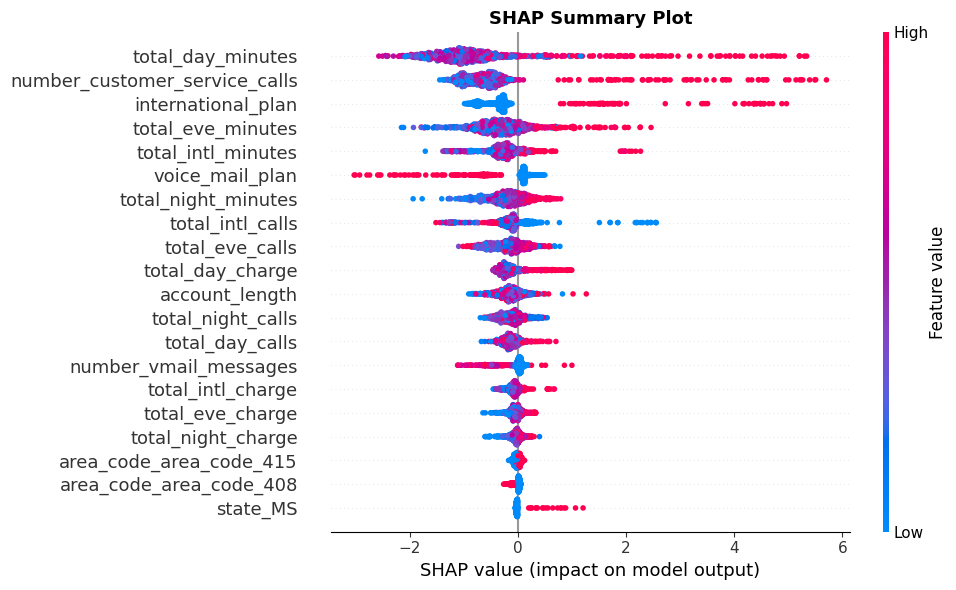

In [35]:
plt.figure(figsize=(10, 6))
shap.summary_plot(sv, X_test, show=False, plot_size=None)
plt.title("SHAP Summary Plot", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## Explain a single high-risk customer

In [36]:
high_risk_idx = np.argmax(y_prob_xgb)
print(f"\n  Customer with highest churn probability: {y_prob_xgb[high_risk_idx]*100:.1f}%")
print(f"\n  Feature contributions (SHAP values for this customer):")
customer_shap = pd.Series(sv[high_risk_idx], index=X_test.columns)
customer_shap = customer_shap.sort_values(key=abs, ascending=False)
for feat, val in customer_shap.items():
    direction = " pushes toward churn" if val > 0 else " reduces churn risk"
    print(f"    {feat:<35} {val:>+.4f}  {direction}")

# Save importance table
importance_df.to_csv("feature_importance.csv", index=False)



  Customer with highest churn probability: 100.0%

  Feature contributions (SHAP values for this customer):
    total_day_minutes                   +4.6717   pushes toward churn
    total_eve_minutes                   +1.2928   pushes toward churn
    total_day_charge                    +0.9139   pushes toward churn
    voice_mail_plan                     +0.4969   pushes toward churn
    total_night_minutes                 +0.4233   pushes toward churn
    number_customer_service_calls       -0.2248   reduces churn risk
    total_intl_calls                    -0.2215   reduces churn risk
    state_MS                            +0.1975   pushes toward churn
    number_vmail_messages               +0.1894   pushes toward churn
    total_night_calls                   -0.1834   reduces churn risk
    total_eve_charge                    +0.1731   pushes toward churn
    international_plan                  -0.1302   reduces churn risk
    total_intl_minutes                  -0.1292   reduc

# SECTION 6 — EARLY WARNING SYSTEM

In [37]:
# We use XGBoost probabilities (better AUC)
# but the interpretation logic comes from what we learned in logistic regression

df_risk = X_test.copy().reset_index(drop=True)
df_risk["churn_probability_%"] = (y_prob_xgb * 100).round(1)
df_risk["actual_churn"]        = y_test.values

# Risk tiers — these thresholds are a business decision, not a model decision
# Adjust them based on your customer success team's capacity
df_risk["risk_tier"] = pd.cut(
    df_risk["churn_probability_%"],
    bins   = [0,  40,  70, 100],
    labels = ["Low", "Medium", "High"]
)

df_risk["customer_id"] = [f"CUST-{str(i).zfill(4)}" for i in range(1, len(df_risk)+1)]
df_risk = df_risk[["customer_id", "churn_probability_%", "risk_tier",
                    "actual_churn"] + list(X_test.columns)]
df_risk = df_risk.sort_values("churn_probability_%", ascending=False).reset_index(drop=True)

print("\n  Risk tier distribution:")
print(df_risk["risk_tier"].value_counts().rename("count").to_string())


  Risk tier distribution:
risk_tier
Low       724
High      104
Medium     22


## REVENUE AT RISK

In [38]:
# Use total day charge × 3 as a monthly revenue proxy
# (day + evening + night charges ≈ total monthly)
charge_cols = ["Total day charge", "Total eve charge",
               "Total night charge", "Total intl charge"]
available   = [c for c in charge_cols if c in df_risk.columns]

if available:
    df_risk["monthly_value_usd"] = df_risk[available].sum(axis=1).round(2)
else:
    df_risk["monthly_value_usd"] = np.random.uniform(20, 120, len(df_risk)).round(2)

tier_summary = df_risk.groupby("risk_tier", observed=True).agg(
    customers     = ("customer_id",        "count"),
    total_rev     = ("monthly_value_usd",  "sum"),
    avg_prob      = ("churn_probability_%","mean"),
).reindex(["High","Medium","Low"])

tier_summary["total_rev_fmt"]  = tier_summary["total_rev"].map("${:,.2f}".format)
tier_summary["avg_prob_fmt"]   = tier_summary["avg_prob"].map("{:.1f}%".format)

print(f"\n  {'Tier':<10} {'Customers':>10}  {'Avg Probability':>16}  {'Revenue at Risk':>16}")
print("  " + "-" * 60)
for tier, row in tier_summary.iterrows():
    print(f"  {tier:<10} {row['customers']:>10}  "
          f"{row['avg_prob_fmt']:>16}  {row['total_rev_fmt']:>16}")

high_risk_rev  = tier_summary.loc["High",  "total_rev"]
total_rev      = tier_summary["total_rev"].sum()
print(f"\n  Total monthly revenue at risk (High tier): ${high_risk_rev:,.2f}")
print(f"  That is {high_risk_rev/total_rev*100:.1f}% of total monthly revenue in this cohort.")



  Tier        Customers   Avg Probability   Revenue at Risk
  ------------------------------------------------------------
  High              104             95.1%         $7,609.00
  Medium             22             49.5%         $1,575.56
  Low               724              4.1%        $50,885.28

  Total monthly revenue at risk (High tier): $7,609.00
  That is 12.7% of total monthly revenue in this cohort.


In [39]:
display_cols = ["customer_id", "churn_probability_%", "risk_tier",
                "monthly_value_usd"]
extra_signal = ["International plan", "Customer service calls",
                "Total day minutes", "Voice mail plan"]
for col in extra_signal:
    if col in df_risk.columns:
        display_cols.append(col)

call_list = df_risk[df_risk["risk_tier"] == "High"][display_cols].head(50)

print(f"\n  Top 50 high-risk customers (sorted by churn probability):\n")
print(call_list.head(10).to_string(index=False))
print(f"  ... ({len(call_list)} total high-risk customers)\n")

call_list.to_csv("early_warning_list.csv", index=False)
df_risk.to_csv("churn_predictions_full.csv", index=False)

print("early_warning_list.csv saved")
print("churn_predictions_full.csv saved")


  Top 50 high-risk customers (sorted by churn probability):

customer_id  churn_probability_% risk_tier  monthly_value_usd
  CUST-0081           100.000000      High             103.37
  CUST-0317            99.900002      High              29.19
  CUST-0252            99.900002      High             105.51
  CUST-0311            99.900002      High             111.36
  CUST-0178            99.800003      High              81.66
  CUST-0037            99.800003      High              85.87
  CUST-0085            99.800003      High              87.67
  CUST-0343            99.800003      High              54.50
  CUST-0709            99.800003      High             112.86
  CUST-0839            99.800003      High              85.87
  ... (50 total high-risk customers)

early_warning_list.csv saved
churn_predictions_full.csv saved


In [41]:
df_risk[df_risk["risk_tier"] == "High"][display_cols]

,customer_id,churn_probability_%,risk_tier,monthly_value_usd
0,CUST-0081,100.000000,High,103.37
1,CUST-0317,99.900002,High,29.19
2,CUST-0252,99.900002,High,105.51
3,CUST-0311,99.900002,High,111.36
4,CUST-0178,99.800003,High,81.66
...,...,...,...,...
99,CUST-0207,81.800003,High,28.22
100,CUST-0156,80.300003,High,21.41
101,CUST-0688,76.000000,High,33.22
102,CUST-0210,75.300003,High,105.41


In [45]:
!pip install loguru

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 1.8 MB/s eta 0:00:00


In [48]:
import pandas as pd
import joblib
from loguru import logger
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

def train_pipeline():
    logger.info("Modules loaded")

    # 1. Load Data
    try:
        df = pd.read_csv("churn.csv")
        logger.info("Data loaded from churn.csv")
    except FileNotFoundError:
        logger.warning("churn.csv not found")
        return # Exit if data not found

    # 2. Preprocessing
    # Manual mapping for Yes/No columns as they appear in the dataset
    yes_no_map = {"yes": 1, "no": 0, "Yes": 1, "No": 0}
    df["international_plan"] = df["international_plan"].map(yes_no_map)
    df["voice_mail_plan"] = df["voice_mail_plan"].map(yes_no_map)

    # Ensure target is integer (bool -> int)
    df["churn"] = df["churn"].map({"yes": 1, "no": 0}).astype(int)

    # Drop non-predictive columns identified in your research
    df.drop(columns=["state", "area_code", "phone_number"], inplace=True, errors="ignore")
    logger.info("Corrected columns processed and identifiers dropped")

    # 3. Split & Train (80/20 split)
    X = df.drop(columns=["churn"])
    y = df["churn"]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    # 4. XGBoost Config
    neg_count = (y_train == 0).sum()
    pos_count = (y_train == 1).sum()
    spw = neg_count / pos_count

    model = XGBClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        use_label_encoder=False,
        random_state=42
    )

    model.fit(X_train, y_train)
    logger.info("XGBoost trained with exact 'bigml' feature names")

    # 5. Save Artifacts
    # Saving features ensures the Streamlit app uses the exact same column order
    joblib.dump({"model": model, "features": list(X.columns)}, "prediction_model.sav")

    # Save X_test as CSV for testing purposes
    X_test.to_csv("X_test.csv", index=False)
    logger.info("X_test saved to X_test.csv")

    logger.info("ML model and feature list saved to prediction_model.sav")

if __name__ == "__main__":
    train_pipeline()


2026-04-16 23:34:02.796 | INFO     | __main__:train_pipeline:8 - Modules loaded
2026-04-16 23:34:02.800 | WARNING  | __main__:train_pipeline:15 - churn.csv not found


In [49]:
train_pipeline()

2026-04-16 23:34:03.303 | INFO     | __main__:train_pipeline:8 - Modules loaded
2026-04-16 23:34:03.311 | WARNING  | __main__:train_pipeline:15 - churn.csv not found


In [51]:
!pip install loguru

In [61]:
import pandas as pd
import joblib
from loguru import logger
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

def train_pipeline():
    logger.info("Modules loaded")

    # 1. Load Data
    try:
        df = pd.read_csv("churn_train.csv")
        logger.info("Data loaded from churn.csv")
    except FileNotFoundError:
        logger.warning("churn_train.csv not found")
        return # Exit if data not found

    # 2. Preprocessing
    # Manual mapping for Yes/No columns as they appear in the dataset
    yes_no_map = {"yes": 1, "no": 0, "Yes": 1, "No": 0}
    df["international_plan"] = df["international_plan"].map(yes_no_map)
    df["voice_mail_plan"] = df["voice_mail_plan"].map(yes_no_map)

    # Ensure target is integer (bool -> int)
    df["churn"] = df["churn"].map({"yes": 1, "no": 0}).astype(int)

    # Drop non-predictive columns identified in your research
    df.drop(columns=["state", "area_code", "phone_number"], inplace=True, errors="ignore")
    logger.info("Corrected columns processed and identifiers dropped")

    # 3. Split & Train (80/20 split)
    X = df.drop(columns=["churn"])
    y = df["churn"]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    # 4. XGBoost Config
    neg_count = (y_train == 0).sum()
    pos_count = (y_train == 1).sum()
    spw = neg_count / pos_count

    model = XGBClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        use_label_encoder=False,
        random_state=42
    )

    model.fit(X_train, y_train)
    logger.info("XGBoost trained with exact 'bigml' feature names")

    # 5. Save Artifacts
    # Saving features ensures the Streamlit app uses the exact same column order
    joblib.dump({"model": model, "features": list(X.columns)}, "prediction_model.sav")

    # Save X_test as CSV for testing purposes
    X_test.to_csv("X_test.csv", index=False)
    logger.info("X_test saved to X_test.csv")

    logger.info("ML model and feature list saved to prediction_model.sav")

if __name__ == "__main__":
    train_pipeline()

2026-04-16 23:46:18.595 | INFO     | __main__:train_pipeline:8 - Modules loaded
2026-04-16 23:46:18.695 | INFO     | __main__:train_pipeline:13 - Data loaded from churn.csv
2026-04-16 23:46:18.718 | INFO     | __main__:train_pipeline:29 - Corrected columns processed and identifiers dropped
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:46:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
2026-04-16 23:46:21.793 | INFO     | __main__:train_pipeline:55 - XGBoost trained with exact 'bigml' feature names
2026-04-16 23:46:21.913 | INFO     | __main__:train_pipeline:63 - X_test saved to X_test.csv
2026-04-16 23:46:21.917 | INFO     | __main__:train_pipeline:65 - ML model and feature list saved to prediction_model.sav
